In [1]:
# ============================================================
# 12. GENERATE FULL GALLERY EMBEDDINGS
# ============================================================

# COMMENTED OUT
# ALREADY GENERATED IN PREVIOUS COMMIT

"""
print("\n[12/15] Generating FULL Gallery Embeddings...\n")

gallery_embeddings = []
gallery_paths = []
gallery_item_ids = []

success_count = 0
failure_count = 0

for idx, row in tqdm(
    gallery_df.iterrows(),
    total=len(gallery_df),
    desc="Generating Full Gallery Embeddings"
):

    try:

        emb = get_cropped_image_embedding(
            row["image_path"]
        )

        gallery_embeddings.append(emb)

        gallery_paths.append(
            row["image_path"]
        )

        gallery_item_ids.append(
            row["item_id"]
        )

        success_count += 1

        if success_count % 500 == 0:

            print(
                f"\nProcessed {success_count} / {len(gallery_df)} images..."
            )

    except Exception as e:

        failure_count += 1

        print("\nERROR:", row["image_path"])
        print(e)

gallery_embeddings = np.array(
    gallery_embeddings
)

print("\nFULL Gallery Embeddings Generated Successfully!")

print("\nSuccessful Embeddings:", success_count)
print("Failed Embeddings:", failure_count)

print("\nGallery Embedding Shape:")
print(gallery_embeddings.shape)
"""

# ============================================================
# 13. SAVE EMBEDDINGS
# ============================================================

# COMMENTED OUT
# ALREADY SAVED IN PREVIOUS COMMIT

"""
print("\n[13/15] Saving Embeddings...\n")

np.save(
    "gallery_embeddings.npy",
    gallery_embeddings
)

np.save(
    "gallery_paths.npy",
    np.array(gallery_paths)
)

np.save(
    "gallery_item_ids.npy",
    np.array(gallery_item_ids)
)

print("Embedding Files Saved Successfully!")
"""

# ============================================================
# 14. SAVE DATAFRAMES
# ============================================================

# COMMENTED OUT
# ALREADY SAVED IN PREVIOUS COMMIT

"""
print("\n[14/15] Saving Dataset DataFrames...\n")

gallery_df.to_csv(
    "gallery_df.csv",
    index=False
)

query_df.to_csv(
    "query_df.csv",
    index=False
)

train_df.to_csv(
    "train_df.csv",
    index=False
)

print("Dataset DataFrames Saved Successfully!")
"""

# ============================================================
# 15. FINAL SUMMARY
# ============================================================

# COMMENTED OUT
# PREVIOUS COMMIT SUMMARY

"""
print("\n================================================")
print("FULL OFFLINE INDEXING PIPELINE COMPLETED!")
print("================================================")

print("\nFINAL SUMMARY:")

print(f"\nTotal Gallery Images Processed: {success_count}")

print(f"Failed Images: {failure_count}")

print(f"\nFinal Embedding Matrix Shape: {gallery_embeddings.shape}")

print("\nFILES GENERATED:")

print("\n1. gallery_embeddings.npy")
print("2. gallery_paths.npy")
print("3. gallery_item_ids.npy")
print("4. gallery_df.csv")
print("5. query_df.csv")
print("6. train_df.csv")

print("\nOffline Retrieval Database Ready!")
"""

'\nprint("\n================================================")\nprint("FULL OFFLINE INDEXING PIPELINE COMPLETED!")\nprint("================================================")\n\nprint("\nFINAL SUMMARY:")\n\nprint(f"\nTotal Gallery Images Processed: {success_count}")\n\nprint(f"Failed Images: {failure_count}")\n\nprint(f"\nFinal Embedding Matrix Shape: {gallery_embeddings.shape}")\n\nprint("\nFILES GENERATED:")\n\nprint("\n1. gallery_embeddings.npy")\nprint("2. gallery_paths.npy")\nprint("3. gallery_item_ids.npy")\nprint("4. gallery_df.csv")\nprint("5. query_df.csv")\nprint("6. train_df.csv")\n\nprint("\nOffline Retrieval Database Ready!")\n'

In [2]:
"""
# ============================================================
# QUERY EMBEDDING + FAISS INDEX PIPELINE
# ============================================================
#
# THIS ENTIRE PIPELINE IS COMMENTED OUT
# BECAUSE:
#
# - Query embeddings already generated
# - FAISS index already created
# - Outputs already saved in previous commit
#
# ============================================================

print("\n[1/12] Installing Dependencies...\n")

!pip install -q faiss-cpu transformers

print("\n[2/12] Importing Libraries...\n")

import os
import cv2
import faiss
import torch
import numpy as np
import pandas as pd

from PIL import Image
from tqdm import tqdm
from transformers import CLIPProcessor, CLIPModel

print("Libraries Imported Successfully!")

print("\n[3/12] Setting Up Device...\n")

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Using Device:", device)

print("\n[4/12] Configuring Paths...\n")

BASE_DATASET_PATH = "/kaggle/input/deepfashion-redwing2/DeepFashion"

NOTEBOOK_OUTPUT_PATH = "/kaggle/input/vr-final-project"

IMG_BASE_PATH = os.path.join(
    BASE_DATASET_PATH,
    "Img"
)

BBOX_FILE = os.path.join(
    BASE_DATASET_PATH,
    "Anno",
    "list_bbox_inshop.txt"
)

print("\n[5/12] Loading Previous Offline Database...\n")

gallery_embeddings = np.load(
    os.path.join(
        NOTEBOOK_OUTPUT_PATH,
        "gallery_embeddings.npy"
    )
)

gallery_paths = np.load(
    os.path.join(
        NOTEBOOK_OUTPUT_PATH,
        "gallery_paths.npy"
    ),
    allow_pickle=True
)

gallery_item_ids = np.load(
    os.path.join(
        NOTEBOOK_OUTPUT_PATH,
        "gallery_item_ids.npy"
    ),
    allow_pickle=True
)

query_df = pd.read_csv(
    os.path.join(
        NOTEBOOK_OUTPUT_PATH,
        "query_df.csv"
    )
)

print("\n[6/12] Loading Bounding Box File...\n")

bbox_df = pd.read_csv(
    BBOX_FILE,
    skiprows=2,
    sep=r"\s+",
    header=None
)

bbox_df.columns = [
    "image_path",
    "clothes_type",
    "pose_type",
    "x1",
    "y1",
    "x2",
    "y2"
]

bbox_lookup = {}

for _, row in tqdm(
    bbox_df.iterrows(),
    total=len(bbox_df),
    desc="Creating BBox Lookup"
):

    bbox_lookup[row["image_path"]] = (
        int(row["x1"]),
        int(row["y1"]),
        int(row["x2"]),
        int(row["y2"])
    )

print("\nBounding Box Lookup Ready!")

print("\n[7/12] Loading CLIP Model...\n")

model = CLIPModel.from_pretrained(
    "openai/clip-vit-base-patch32"
).to(device)

processor = CLIPProcessor.from_pretrained(
    "openai/clip-vit-base-patch32"
)

model.eval()

print("\nCLIP Model Loaded Successfully!")

print("\n[8/12] Creating Embedding Function...\n")

def get_cropped_image_embedding(image_path):

    full_image_path = os.path.join(
        IMG_BASE_PATH,
        image_path
    )

    image = cv2.imread(full_image_path)

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    x1, y1, x2, y2 = bbox_lookup[image_path]

    cropped_image = image[y1:y2, x1:x2]

    cropped_pil = Image.fromarray(cropped_image)

    inputs = processor(
        images=cropped_pil,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():

        outputs = model.vision_model(
            pixel_values=inputs["pixel_values"]
        )

        image_features = outputs.pooler_output

    image_features = image_features / image_features.norm(
        dim=-1,
        keepdim=True
    )

    return image_features.cpu().numpy()[0]

print("\n[9/12] Generating Query Embeddings...\n")

query_embeddings = []
query_paths = []
query_item_ids = []

for _, row in tqdm(
    query_df.iterrows(),
    total=len(query_df)
):

    emb = get_cropped_image_embedding(
        row["image_path"]
    )

    query_embeddings.append(emb)

    query_paths.append(
        row["image_path"]
    )

    query_item_ids.append(
        row["item_id"]
    )

query_embeddings = np.array(query_embeddings)

print("\n[10/12] Creating FAISS Index...\n")

gallery_embeddings = gallery_embeddings.astype(
    np.float32
)

embedding_dim = gallery_embeddings.shape[1]

index = faiss.IndexFlatIP(
    embedding_dim
)

index.add(
    gallery_embeddings
)

print("\n[11/12] Saving Query Embeddings...\n")

np.save(
    "query_embeddings.npy",
    query_embeddings
)

np.save(
    "query_paths.npy",
    np.array(query_paths)
)

np.save(
    "query_item_ids.npy",
    np.array(query_item_ids)
)

print("\n[12/12] Saving FAISS Index...\n")

faiss.write_index(
    index,
    "fashion_faiss.index"
)

print("\nQUERY EMBEDDING + FAISS PIPELINE COMPLETED!")

"""

<>:94: SyntaxWarning: invalid escape sequence '\s'
<>:94: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_22/343474966.py:94: SyntaxWarning: invalid escape sequence '\s'
  sep=r"\s+",


'\n# ============================================================\n# QUERY EMBEDDING + FAISS INDEX PIPELINE\n# ============================================================\n#\n# THIS ENTIRE PIPELINE IS COMMENTED OUT\n# BECAUSE:\n#\n# - Query embeddings already generated\n# - FAISS index already created\n# - Outputs already saved in previous commit\n#\n# ============================================================\n\nprint("\n[1/12] Installing Dependencies...\n")\n\n!pip install -q faiss-cpu transformers\n\nprint("\n[2/12] Importing Libraries...\n")\n\nimport os\nimport cv2\nimport faiss\nimport torch\nimport numpy as np\nimport pandas as pd\n\nfrom PIL import Image\nfrom tqdm import tqdm\nfrom transformers import CLIPProcessor, CLIPModel\n\nprint("Libraries Imported Successfully!")\n\nprint("\n[3/12] Setting Up Device...\n")\n\ndevice = "cuda" if torch.cuda.is_available() else "cpu"\n\nprint("Using Device:", device)\n\nprint("\n[4/12] Configuring Paths...\n")\n\nBASE_DATASET_PATH = "/k

In [3]:
"""
# ============================================================
# FINAL CORRECTED MULTIMODAL RETRIEVAL PIPELINE
# ============================================================
#
# THIS ENTIRE SECTION IS COMMENTED OUT
#
# REASON:
# - Multimodal retrieval database already created
# - BLIP captions already generated
# - CLIP image embeddings already generated
# - CLIP text embeddings already generated
# - Fusion embeddings already generated
# - Fusion FAISS index already generated
#
# ============================================================

print("\n[1/16] Installing Dependencies...\n")

!pip install -q transformers accelerate sentencepiece faiss-cpu

print("\nDependencies Installed Successfully!")

print("\n[2/16] Importing Libraries...\n")

import os
import cv2
import faiss
import torch
import numpy as np
import pandas as pd

from PIL import Image
from tqdm import tqdm

from transformers import (
    CLIPProcessor,
    CLIPModel,
    BlipProcessor,
    BlipForConditionalGeneration
)

print("Libraries Imported Successfully!")

print("\n[3/16] Setting Up Device...\n")

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Using Device:", device)

print("\n[4/16] Configuring Paths...\n")

BASE_DATASET_PATH = "/kaggle/input/datasets/kunalnarang47/deepfashion-redwing2/DeepFashion"

MODEL_FILES_PATH = "/kaggle/input/datasets/kunalnarang47/model-files-vr"

IMG_BASE_PATH = os.path.join(
    BASE_DATASET_PATH,
    "Img"
)

BBOX_FILE = os.path.join(
    BASE_DATASET_PATH,
    "Anno",
    "list_bbox_inshop.txt"
)

print("Paths Configured Successfully!")

print("\n[5/16] Loading Retrieval Database...\n")

gallery_paths = np.load(
    os.path.join(
        MODEL_FILES_PATH,
        "gallery_paths.npy"
    ),
    allow_pickle=True
)

gallery_item_ids = np.load(
    os.path.join(
        MODEL_FILES_PATH,
        "gallery_item_ids.npy"
    ),
    allow_pickle=True
)

query_paths = np.load(
    os.path.join(
        MODEL_FILES_PATH,
        "query_paths.npy"
    ),
    allow_pickle=True
)

query_item_ids = np.load(
    os.path.join(
        MODEL_FILES_PATH,
        "query_item_ids.npy"
    ),
    allow_pickle=True
)

print("Gallery Images:", len(gallery_paths))
print("Query Images:", len(query_paths))

print("\n[6/16] Loading Bounding Box File...\n")

bbox_df = pd.read_csv(
    BBOX_FILE,
    skiprows=2,
    sep=r"\s+",
    header=None
)

bbox_df.columns = [
    "image_path",
    "clothes_type",
    "pose_type",
    "x1",
    "y1",
    "x2",
    "y2"
]

bbox_lookup = {}

for _, row in tqdm(
    bbox_df.iterrows(),
    total=len(bbox_df),
    desc="Creating BBox Lookup"
):

    bbox_lookup[row["image_path"]] = (
        int(row["x1"]),
        int(row["y1"]),
        int(row["x2"]),
        int(row["y2"])
    )

print("\nBounding Box Lookup Ready!")

print("\n[7/16] Loading CLIP Model...\n")

clip_model = CLIPModel.from_pretrained(
    "openai/clip-vit-base-patch32"
).to(device)

clip_processor = CLIPProcessor.from_pretrained(
    "openai/clip-vit-base-patch32"
)

clip_model.eval()

print("\nCLIP Model Loaded Successfully!")

print("\n[8/16] Loading BLIP Model...\n")

blip_processor = BlipProcessor.from_pretrained(
    "Salesforce/blip-image-captioning-large"
)

blip_model = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-large",
    torch_dtype=torch.float16
).to(device)

blip_model.eval()

print("\nBLIP Model Loaded Successfully!")

print("\n[9/16] Creating Crop Function...\n")

def load_cropped_image(image_path):

    full_image_path = os.path.join(
        IMG_BASE_PATH,
        image_path
    )

    image = cv2.imread(full_image_path)

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    x1, y1, x2, y2 = bbox_lookup[image_path]

    cropped_image = image[y1:y2, x1:x2]

    cropped_pil = Image.fromarray(cropped_image)

    return cropped_pil

print("Crop Function Ready!")

print("\n[10/16] Creating Image Embedding Function...\n")

def get_image_embedding(pil_image):

    inputs = clip_processor(
        images=pil_image,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():

        vision_outputs = clip_model.vision_model(
            pixel_values=inputs["pixel_values"]
        )

        image_features = clip_model.visual_projection(
            vision_outputs.pooler_output
        )

    image_features = image_features / torch.norm(
        image_features,
        dim=-1,
        keepdim=True
    )

    return image_features.cpu().numpy()[0]

print("Image Embedding Function Ready!")

print("\n[11/16] Creating Caption Function...\n")

def generate_caption(pil_image):

    inputs = blip_processor(
        images=pil_image,
        return_tensors="pt"
    ).to(device, torch.float16)

    with torch.no_grad():

        generated_ids = blip_model.generate(
            **inputs,
            max_new_tokens=30
        )

    caption = blip_processor.batch_decode(
        generated_ids,
        skip_special_tokens=True
    )[0].strip()

    return caption

print("Caption Function Ready!")

print("\n[12/16] Creating Text Embedding Function...\n")

def get_text_embedding(text):

    inputs = clip_processor.tokenizer(
        text,
        return_tensors="pt",
        padding=True,
        truncation=True
    ).to(device)

    with torch.no_grad():

        text_outputs = clip_model.text_model(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"]
        )

        text_features = clip_model.text_projection(
            text_outputs.pooler_output
        )

    text_features = text_features / torch.norm(
        text_features,
        dim=-1,
        keepdim=True
    )

    return text_features.cpu().numpy()[0]

print("Text Embedding Function Ready!")

print("\n[13/16] Generating Gallery Multimodal Features...\n")

gallery_image_embeddings = []

gallery_captions = []

gallery_text_embeddings = []

success_count = 0
failure_count = 0

for image_path in tqdm(
    gallery_paths,
    total=len(gallery_paths),
    desc="Processing Gallery Images"
):

    try:

        cropped_image = load_cropped_image(
            image_path
        )

        image_embedding = get_image_embedding(
            cropped_image
        )

        caption = generate_caption(
            cropped_image
        )

        text_embedding = get_text_embedding(
            caption
        )

        gallery_image_embeddings.append(
            image_embedding
        )

        gallery_captions.append(
            caption
        )

        gallery_text_embeddings.append(
            text_embedding
        )

        success_count += 1

        if success_count % 100 == 0:

            print(
                f"\nProcessed {success_count} / {len(gallery_paths)} images..."
            )

            print("Latest Caption:", caption)

    except Exception as e:

        failure_count += 1

        print("\nERROR:", image_path)
        print(e)

gallery_image_embeddings = np.array(
    gallery_image_embeddings
)

gallery_text_embeddings = np.array(
    gallery_text_embeddings
)

print("\nGallery Processing Completed!")

print("\nSuccessful:", success_count)
print("Failed:", failure_count)

print("\nImage Embedding Shape:")
print(gallery_image_embeddings.shape)

print("\nText Embedding Shape:")
print(gallery_text_embeddings.shape)

print("\n[14/16] Creating Fusion Embeddings...\n")

alpha = 0.7
beta = 0.3

gallery_fusion_embeddings = (
    alpha * gallery_image_embeddings
    +
    beta * gallery_text_embeddings
)

norms = np.linalg.norm(
    gallery_fusion_embeddings,
    axis=1,
    keepdims=True
)

gallery_fusion_embeddings = (
    gallery_fusion_embeddings / norms
)

print("\nFusion Embeddings Created Successfully!")

print(
    "Fusion Embedding Shape:",
    gallery_fusion_embeddings.shape
)

print("\n[15/16] Creating Fusion FAISS Index...\n")

gallery_fusion_embeddings = gallery_fusion_embeddings.astype(
    np.float32
)

embedding_dim = gallery_fusion_embeddings.shape[1]

fusion_index = faiss.IndexFlatIP(
    embedding_dim
)

fusion_index.add(
    gallery_fusion_embeddings
)

print("\nFusion FAISS Index Created Successfully!")

print("Indexed Embeddings:", fusion_index.ntotal)

print("\n[16/16] Saving Multimodal Retrieval Database...\n")

np.save(
    "gallery_image_embeddings_512.npy",
    gallery_image_embeddings
)

np.save(
    "gallery_captions.npy",
    np.array(gallery_captions)
)

np.save(
    "gallery_text_embeddings.npy",
    gallery_text_embeddings
)

np.save(
    "gallery_fusion_embeddings.npy",
    gallery_fusion_embeddings
)

faiss.write_index(
    fusion_index,
    "fusion_faiss.index"
)

print("\nALL FILES SAVED SUCCESSFULLY!")

print("\n================================================")
print("FINAL MULTIMODAL RETRIEVAL PIPELINE COMPLETED!")
print("================================================")

print("\nFILES GENERATED:")

print("\n1. gallery_image_embeddings_512.npy")
print("2. gallery_captions.npy")
print("3. gallery_text_embeddings.npy")
print("4. gallery_fusion_embeddings.npy")
print("5. fusion_faiss.index")

print("\nAdvanced Multimodal Retrieval Database Ready!")

"""

<>:112: SyntaxWarning: invalid escape sequence '\s'
<>:112: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_22/529197786.py:112: SyntaxWarning: invalid escape sequence '\s'
  sep=r"\s+",


'\n# ============================================================\n# FINAL CORRECTED MULTIMODAL RETRIEVAL PIPELINE\n# ============================================================\n#\n# THIS ENTIRE SECTION IS COMMENTED OUT\n#\n# REASON:\n# - Multimodal retrieval database already created\n# - BLIP captions already generated\n# - CLIP image embeddings already generated\n# - CLIP text embeddings already generated\n# - Fusion embeddings already generated\n# - Fusion FAISS index already generated\n#\n# ============================================================\n\nprint("\n[1/16] Installing Dependencies...\n")\n\n!pip install -q transformers accelerate sentencepiece faiss-cpu\n\nprint("\nDependencies Installed Successfully!")\n\nprint("\n[2/16] Importing Libraries...\n")\n\nimport os\nimport cv2\nimport faiss\nimport torch\nimport numpy as np\nimport pandas as pd\n\nfrom PIL import Image\nfrom tqdm import tqdm\n\nfrom transformers import (\n    CLIPProcessor,\n    CLIPModel,\n    BlipProces

In [4]:
# ============================================================
# FASHION CLIP FINE-TUNING PIPELINE
# ============================================================
#
# TRAINING METHOD:
#
# Triplet Loss Fine-Tuning
#
# Anchor Image
# Positive Image (same item_id)
# Negative Image (different item_id)
#
# ============================================================

# ============================================================
# 1. INSTALL DEPENDENCIES
# ============================================================

#print("\n[1/14] Installing Dependencies...\n")

#!pip install -q transformers accelerate sentencepiece

#print("\nDependencies Installed Successfully!")

# ============================================================
# 2. IMPORT LIBRARIES
# ============================================================

#print("\n[2/14] Importing Libraries...\n")

#import os
#import cv2
#import random
#import numpy as np
#import pandas as pd

#from PIL import Image
#from tqdm import tqdm

#import torch
#import torch.nn as nn
#import torch.optim as optim

#from torch.utils.data import Dataset, DataLoader

#from transformers import (
#    CLIPProcessor,
#    CLIPModel
#)

#print("Libraries Imported Successfully!")

# ============================================================
# 3. DEVICE SETUP
# ============================================================

#print("\n[3/14] Setting Up Device...\n")

#device = "cuda" if torch.cuda.is_available() else "cpu"

#print("Using Device:", device)

# ============================================================
# 4. PATH CONFIGURATION
# ============================================================

#print("\n[4/14] Configuring Paths...\n")

#BASE_DATASET_PATH = "/kaggle/input/datasets/kunalnarang47/deepfashion-redwing2/DeepFashion"

#MODEL_FILES_PATH = "/kaggle/input/datasets/kunalnarang47/model-files-vr"

#IMG_BASE_PATH = os.path.join(
#    BASE_DATASET_PATH,
#    "Img"
#)

#BBOX_FILE = os.path.join(
#    BASE_DATASET_PATH,
#    "Anno",
#    "list_bbox_inshop.txt"
#)

#TRAIN_DF_PATH = os.path.join(
#    MODEL_FILES_PATH,
#    "train_df.csv"
#)

#print("Paths Configured Successfully!")

# ============================================================
# 5. LOAD TRAINING DATA
# ============================================================

#print("\n[5/14] Loading Training Data...\n")

#train_df = pd.read_csv(
#    TRAIN_DF_PATH
#)

#print("Training Images:", len(train_df))

#print("\nDataset Preview:\n")

#print(train_df.head())

# ============================================================
# 6. LOAD BOUNDING BOX FILE
# ============================================================

#print("\n[6/14] Loading Bounding Boxes...\n")

#bbox_df = pd.read_csv(
#    BBOX_FILE,
#    skiprows=2,
#    sep=r"\s+",
#    header=None
#)

#bbox_df.columns = [
#    "image_path",
#    "clothes_type",
#    "pose_type",
#    "x1",
#    "y1",
#    "x2",
#    "y2"
#]

#bbox_lookup = {}

#for _, row in tqdm(
#    bbox_df.iterrows(),
#    total=len(bbox_df),
#    desc="Creating BBox Lookup"
#):

#    bbox_lookup[row["image_path"]] = (
#        int(row["x1"]),
#        int(row["y1"]),
#        int(row["x2"]),
#        int(row["y2"])
#    )

#print("\nBounding Box Lookup Ready!")

# ============================================================
# 7. LOAD CLIP MODEL
# ============================================================

#print("\n[7/14] Loading CLIP Model...\n")

#clip_model = CLIPModel.from_pretrained(
#    "openai/clip-vit-base-patch32"
#).to(device)

#clip_processor = CLIPProcessor.from_pretrained(
#    "openai/clip-vit-base-patch32"
#)

#clip_model.train()

#print("\nCLIP Model Loaded Successfully!")

# ============================================================
# 8. GROUP IMAGES BY ITEM ID
# ============================================================

#print("\n[8/14] Grouping Images By Item ID...\n")

#item_groups = train_df.groupby(
#    "item_id"
#)["image_path"].apply(list).to_dict()

#valid_item_ids = [
#    item_id
#    for item_id, images in item_groups.items()
#    if len(images) >= 2
#]

#print("Valid Training Item IDs:", len(valid_item_ids))

# ============================================================
# 9. TRIPLET DATASET
# ============================================================

#print("\n[9/14] Creating Triplet Dataset...\n")

#class FashionTripletDataset(Dataset):

#    def __init__(
#        self,
#        item_groups,
#        valid_item_ids,
#        bbox_lookup,
#        processor
#    ):

#        self.item_groups = item_groups

#        self.valid_item_ids = valid_item_ids

#        self.bbox_lookup = bbox_lookup

#        self.processor = processor

#    # --------------------------------------------------------
#    # DATASET LENGTH
#    # --------------------------------------------------------

#    def __len__(self):

#        return len(self.valid_item_ids)

#    # --------------------------------------------------------
#    # LOAD CROPPED IMAGE
#    # --------------------------------------------------------

#    def load_image(self, image_path):

#        full_image_path = os.path.join(
#            IMG_BASE_PATH,
#            image_path
#        )

#        image = cv2.imread(full_image_path)

#        image = cv2.cvtColor(
#            image,
#            cv2.COLOR_BGR2RGB
#        )

#        x1, y1, x2, y2 = self.bbox_lookup[
#            image_path
#        ]

#        cropped = image[y1:y2, x1:x2]

#        pil_image = Image.fromarray(cropped)

#        return pil_image

#    # --------------------------------------------------------
#    # GET TRIPLET
#    # --------------------------------------------------------

#    def __getitem__(self, idx):

#        # ----------------------------------------------------
#        # SELECT ANCHOR ITEM
#        # ----------------------------------------------------

#        anchor_item_id = self.valid_item_ids[idx]

#        anchor_images = self.item_groups[
#            anchor_item_id
#        ]

#        # ----------------------------------------------------
#        # SELECT ANCHOR + POSITIVE
#        # ----------------------------------------------------

#        anchor_path, positive_path = random.sample(
#            anchor_images,
#            2
#        )

#        # ----------------------------------------------------
#        # SELECT NEGATIVE
#        # ----------------------------------------------------

#        negative_item_id = random.choice(
#            self.valid_item_ids
#        )

#        while negative_item_id == anchor_item_id:

#            negative_item_id = random.choice(
#                self.valid_item_ids
#            )

#        negative_path = random.choice(
#            self.item_groups[negative_item_id]
#        )

#        # ----------------------------------------------------
#        # LOAD IMAGES
#        # ----------------------------------------------------

#        anchor_image = self.load_image(
#            anchor_path
#        )

#        positive_image = self.load_image(
#            positive_path
#        )

#        negative_image = self.load_image(
#            negative_path
#        )

#        # ----------------------------------------------------
#        # PROCESS IMAGES
#        # ----------------------------------------------------

#        anchor_inputs = self.processor(
#            images=anchor_image,
#            return_tensors="pt"
#        )

#        positive_inputs = self.processor(
#            images=positive_image,
#            return_tensors="pt"
#        )

#        negative_inputs = self.processor(
#            images=negative_image,
#            return_tensors="pt"
#        )

#        return (
#            anchor_inputs["pixel_values"].squeeze(0),
#            positive_inputs["pixel_values"].squeeze(0),
#            negative_inputs["pixel_values"].squeeze(0)
#        )

#print("Triplet Dataset Ready!")

# ============================================================
# 10. CREATE DATALOADER
# ============================================================

#print("\n[10/14] Creating DataLoader...\n")

#train_dataset = FashionTripletDataset(
#    item_groups=item_groups,
#    valid_item_ids=valid_item_ids,
#    bbox_lookup=bbox_lookup,
#    processor=clip_processor
#)

#train_loader = DataLoader(
#    train_dataset,
#    batch_size=16,
#    shuffle=True,
#    num_workers=2
#)

#print("Training Batches:", len(train_loader))

# ============================================================
# 11. LOSS + OPTIMIZER
# ============================================================

#print("\n[11/14] Setting Up Training Components...\n")

#triplet_loss = nn.TripletMarginLoss(
#    margin=0.3
#)

#optimizer = optim.AdamW(
#    clip_model.parameters(),
#    lr=1e-5
#)

#print("Loss and Optimizer Ready!")

# ============================================================
# 12. IMAGE EMBEDDING FUNCTION
# ============================================================

#print("\n[12/14] Creating Embedding Function...\n")

#def get_projected_features(pixel_values):

#    vision_outputs = clip_model.vision_model(
#        pixel_values=pixel_values
#    )

#    image_features = clip_model.visual_projection(
#        vision_outputs.pooler_output
#    )

#    image_features = image_features / torch.norm(
#        image_features,
#        dim=-1,
#        keepdim=True
#    )

#    return image_features

#print("Embedding Function Ready!")

# ============================================================
# 13. TRAINING LOOP
# ============================================================

#print("\n[13/14] Starting CLIP Fine-Tuning...\n")

#EPOCHS = 20

#best_loss = float("inf")

#for epoch in range(EPOCHS):

#    print(f"\n========== EPOCH {epoch+1}/{EPOCHS} ==========\n")

#    epoch_loss = 0

#    clip_model.train()

#    progress_bar = tqdm(
#        train_loader,
#        desc=f"Training Epoch {epoch+1}"
#    )

#    for batch_idx, batch in enumerate(progress_bar):

#        anchor_pixels = batch[0].to(device)

#        positive_pixels = batch[1].to(device)

#        negative_pixels = batch[2].to(device)

#        # ----------------------------------------------------
#        # EMBEDDINGS
#        # ----------------------------------------------------

#        anchor_embeddings = get_projected_features(
#            anchor_pixels
#        )

#        positive_embeddings = get_projected_features(
#            positive_pixels
#        )

#        negative_embeddings = get_projected_features(
#            negative_pixels
#        )

#        # ----------------------------------------------------
#        # TRIPLET LOSS
#        # ----------------------------------------------------

#        loss = triplet_loss(
#            anchor_embeddings,
#            positive_embeddings,
#            negative_embeddings
#        )

#        # ----------------------------------------------------
#        # BACKPROP
#        # ----------------------------------------------------

#        optimizer.zero_grad()

#        loss.backward()

#        optimizer.step()

#        epoch_loss += loss.item()

#        progress_bar.set_postfix({
#            "Loss": loss.item()
#        })

#        # ----------------------------------------------------
#        # PERIODIC LOGGING
#        # ----------------------------------------------------

#        if batch_idx % 100 == 0:

#            print(
#                f"\nBatch {batch_idx}/{len(train_loader)}"
#            )

#            print(
#                f"Current Loss: {loss.item():.4f}"
#            )

#    # --------------------------------------------------------
#    # EPOCH SUMMARY
#    # --------------------------------------------------------

#    avg_loss = epoch_loss / len(train_loader)

#    print(
#        f"\nEpoch {epoch+1} Average Loss: {avg_loss:.4f}"
#    )

#    # --------------------------------------------------------
#    # SAVE BEST MODEL
#    # --------------------------------------------------------

#    if avg_loss < best_loss:

#        best_loss = avg_loss

#        torch.save(
#            clip_model.state_dict(),
#            "best_fashion_clip.pth"
#        )

#        print(
#            "\nBest Model Saved!"
#        )

# ============================================================
# 14. FINAL SAVE
# ============================================================

#print("\n[14/14] Saving Final Fine-Tuned Model...\n")

#torch.save(
#    clip_model.state_dict(),
#    "final_fashion_clip.pth"
#)

#print("\n================================================")
#print("FASHION CLIP FINE-TUNING COMPLETED!")
#print("================================================")

#print("\nFILES GENERATED:")

#print("\n1. best_fashion_clip.pth")
#print("2. final_fashion_clip.pth")

#print("\nOffline Training Phase Complete!")

In [5]:
# ============================================================
# FINAL OPTIMIZED RETRIEVAL DATABASE GENERATION
# ============================================================
#
# USES:
# - Fine-tuned Fashion CLIP
# - BLIP semantic captions
# - Multimodal fusion
#
# OUTPUT:
# - Final optimized retrieval database
#
# ============================================================

"""
# ============================================================
# 1. INSTALL DEPENDENCIES
# ============================================================

print("\n[1/16] Installing Dependencies...\n")

!pip install -q transformers accelerate sentencepiece faiss-cpu

print("\nDependencies Installed Successfully!")

# ============================================================
# 2. IMPORT LIBRARIES
# ============================================================

print("\n[2/16] Importing Libraries...\n")

import os
import cv2
import faiss
import torch
import numpy as np
import pandas as pd

from PIL import Image
from tqdm import tqdm

from transformers import (
    CLIPProcessor,
    CLIPModel,
    BlipProcessor,
    BlipForConditionalGeneration
)

print("Libraries Imported Successfully!")

# ============================================================
# 3. DEVICE SETUP
# ============================================================

print("\n[3/16] Setting Up Device...\n")

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Using Device:", device)

# ============================================================
# 4. PATH CONFIGURATION
# ============================================================

print("\n[4/16] Configuring Paths...\n")

BASE_DATASET_PATH = "/kaggle/input/datasets/kunalnarang47/deepfashion-redwing2/DeepFashion"

MODEL_FILES_PATH = "/kaggle/input/datasets/kunalnarang47/model-files-vr"

IMG_BASE_PATH = os.path.join(
    BASE_DATASET_PATH,
    "Img"
)

BBOX_FILE = os.path.join(
    BASE_DATASET_PATH,
    "Anno",
    "list_bbox_inshop.txt"
)

BEST_MODEL_PATH = "/kaggle/input/datasets/kunalnarang47/model-files-vr/best_fashion_clip.pth"

print("Paths Configured Successfully!")

# ============================================================
# 5. LOAD DATABASE FILES
# ============================================================

print("\n[5/16] Loading Retrieval Database...\n")

gallery_paths = np.load(
    os.path.join(
        MODEL_FILES_PATH,
        "gallery_paths.npy"
    ),
    allow_pickle=True
)

gallery_item_ids = np.load(
    os.path.join(
        MODEL_FILES_PATH,
        "gallery_item_ids.npy"
    ),
    allow_pickle=True
)

query_paths = np.load(
    os.path.join(
        MODEL_FILES_PATH,
        "query_paths.npy"
    ),
    allow_pickle=True
)

query_item_ids = np.load(
    os.path.join(
        MODEL_FILES_PATH,
        "query_item_ids.npy"
    ),
    allow_pickle=True
)

print("Gallery Images:", len(gallery_paths))
print("Query Images:", len(query_paths))

# ============================================================
# 6. LOAD BOUNDING BOX FILE
# ============================================================

print("\n[6/16] Loading Bounding Boxes...\n")

bbox_df = pd.read_csv(
    BBOX_FILE,
    skiprows=2,
    sep=r"\s+",
    header=None
)

bbox_df.columns = [
    "image_path",
    "clothes_type",
    "pose_type",
    "x1",
    "y1",
    "x2",
    "y2"
]

bbox_lookup = {}

for _, row in tqdm(
    bbox_df.iterrows(),
    total=len(bbox_df),
    desc="Creating BBox Lookup"
):

    bbox_lookup[row["image_path"]] = (
        int(row["x1"]),
        int(row["y1"]),
        int(row["x2"]),
        int(row["y2"])
    )

print("\nBounding Box Lookup Ready!")

# ============================================================
# 7. LOAD FINE-TUNED CLIP MODEL
# ============================================================

print("\n[7/16] Loading Fine-Tuned Fashion CLIP...\n")

clip_model = CLIPModel.from_pretrained(
    "openai/clip-vit-base-patch32"
).to(device)

clip_model.load_state_dict(
    torch.load(
        BEST_MODEL_PATH,
        map_location=device
    )
)

clip_processor = CLIPProcessor.from_pretrained(
    "openai/clip-vit-base-patch32"
)

clip_model.eval()

print("\nFine-Tuned Fashion CLIP Loaded Successfully!")

# ============================================================
# 8. LOAD BLIP MODEL
# ============================================================

print("\n[8/16] Loading BLIP Model...\n")

blip_processor = BlipProcessor.from_pretrained(
    "Salesforce/blip-image-captioning-large"
)

blip_model = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-large",
    torch_dtype=torch.float16
).to(device)

blip_model.eval()

print("\nBLIP Model Loaded Successfully!")

# ============================================================
# 9. IMAGE CROP FUNCTION
# ============================================================

print("\n[9/16] Creating Crop Function...\n")

def load_cropped_image(image_path):

    full_image_path = os.path.join(
        IMG_BASE_PATH,
        image_path
    )

    image = cv2.imread(full_image_path)

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    x1, y1, x2, y2 = bbox_lookup[image_path]

    cropped_image = image[y1:y2, x1:x2]

    cropped_pil = Image.fromarray(cropped_image)

    return cropped_pil

print("Crop Function Ready!")

# ============================================================
# 10. IMAGE EMBEDDING FUNCTION
# ============================================================

print("\n[10/16] Creating Image Embedding Function...\n")

def get_image_embedding(pil_image):

    inputs = clip_processor(
        images=pil_image,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():

        vision_outputs = clip_model.vision_model(
            pixel_values=inputs["pixel_values"]
        )

        image_features = clip_model.visual_projection(
            vision_outputs.pooler_output
        )

    image_features = image_features / torch.norm(
        image_features,
        dim=-1,
        keepdim=True
    )

    return image_features.cpu().numpy()[0]

print("Image Embedding Function Ready!")

# ============================================================
# 11. BLIP CAPTION FUNCTION
# ============================================================

print("\n[11/16] Creating Caption Function...\n")

def generate_caption(pil_image):

    inputs = blip_processor(
        images=pil_image,
        return_tensors="pt"
    ).to(device, torch.float16)

    with torch.no_grad():

        generated_ids = blip_model.generate(
            **inputs,
            max_new_tokens=30
        )

    caption = blip_processor.batch_decode(
        generated_ids,
        skip_special_tokens=True
    )[0].strip()

    return caption

print("Caption Function Ready!")

# ============================================================
# 12. TEXT EMBEDDING FUNCTION
# ============================================================

print("\n[12/16] Creating Text Embedding Function...\n")

def get_text_embedding(text):

    inputs = clip_processor.tokenizer(
        text,
        return_tensors="pt",
        padding=True,
        truncation=True
    ).to(device)

    with torch.no_grad():

        text_outputs = clip_model.text_model(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"]
        )

        text_features = clip_model.text_projection(
            text_outputs.pooler_output
        )

    text_features = text_features / torch.norm(
        text_features,
        dim=-1,
        keepdim=True
    )

    return text_features.cpu().numpy()[0]

print("Text Embedding Function Ready!")

# ============================================================
# 13. GENERATE OPTIMIZED GALLERY DATABASE
# ============================================================

print("\n[13/16] Generating Optimized Gallery Database...\n")

gallery_image_embeddings = []

gallery_captions = []

gallery_text_embeddings = []

success_count = 0
failure_count = 0

for image_path in tqdm(
    gallery_paths,
    total=len(gallery_paths),
    desc="Processing Gallery Images"
):

    try:

        cropped_image = load_cropped_image(
            image_path
        )

        # ----------------------------------------------------
        # IMAGE EMBEDDING
        # ----------------------------------------------------

        image_embedding = get_image_embedding(
            cropped_image
        )

        # ----------------------------------------------------
        # BLIP CAPTION
        # ----------------------------------------------------

        caption = generate_caption(
            cropped_image
        )

        # ----------------------------------------------------
        # TEXT EMBEDDING
        # ----------------------------------------------------

        text_embedding = get_text_embedding(
            caption
        )

        # ----------------------------------------------------
        # STORE RESULTS
        # ----------------------------------------------------

        gallery_image_embeddings.append(
            image_embedding
        )

        gallery_captions.append(
            caption
        )

        gallery_text_embeddings.append(
            text_embedding
        )

        success_count += 1

        if success_count % 100 == 0:

            print(
                f"\nProcessed {success_count} / {len(gallery_paths)} images..."
            )

            print("Latest Caption:", caption)

    except Exception as e:

        failure_count += 1

        print("\nERROR:", image_path)
        print(e)

# ============================================================
# CONVERT TO NUMPY
# ============================================================

gallery_image_embeddings = np.array(
    gallery_image_embeddings
)

gallery_text_embeddings = np.array(
    gallery_text_embeddings
)

print("\nGallery Processing Completed!")

print("\nSuccessful:", success_count)
print("Failed:", failure_count)

print("\nImage Embedding Shape:")
print(gallery_image_embeddings.shape)

print("\nText Embedding Shape:")
print(gallery_text_embeddings.shape)

# ============================================================
# 14. MULTIMODAL FUSION
# ============================================================

print("\n[14/16] Creating Optimized Fusion Embeddings...\n")

alpha = 0.7
beta = 0.3

gallery_fusion_embeddings = (
    alpha * gallery_image_embeddings
    +
    beta * gallery_text_embeddings
)

# ------------------------------------------------------------
# NORMALIZE
# ------------------------------------------------------------

norms = np.linalg.norm(
    gallery_fusion_embeddings,
    axis=1,
    keepdims=True
)

gallery_fusion_embeddings = (
    gallery_fusion_embeddings / norms
)

print("\nOptimized Fusion Embeddings Created Successfully!")

print(
    "Fusion Embedding Shape:",
    gallery_fusion_embeddings.shape
)

# ============================================================
# 15. CREATE FINAL FAISS INDEX
# ============================================================

print("\n[15/16] Creating Final FAISS Index...\n")

gallery_fusion_embeddings = gallery_fusion_embeddings.astype(
    np.float32
)

embedding_dim = gallery_fusion_embeddings.shape[1]

final_fusion_index = faiss.IndexFlatIP(
    embedding_dim
)

final_fusion_index.add(
    gallery_fusion_embeddings
)

print("\nFinal FAISS Index Created Successfully!")

print("Indexed Embeddings:", final_fusion_index.ntotal)

# ============================================================
# 16. SAVE FINAL DATABASE
# ============================================================

print("\n[16/16] Saving Final Optimized Retrieval Database...\n")

# ------------------------------------------------------------
# IMAGE EMBEDDINGS
# ------------------------------------------------------------

np.save(
    "optimized_gallery_image_embeddings.npy",
    gallery_image_embeddings
)

# ------------------------------------------------------------
# CAPTIONS
# ------------------------------------------------------------

np.save(
    "optimized_gallery_captions.npy",
    np.array(gallery_captions)
)

# ------------------------------------------------------------
# TEXT EMBEDDINGS
# ------------------------------------------------------------

np.save(
    "optimized_gallery_text_embeddings.npy",
    gallery_text_embeddings
)

# ------------------------------------------------------------
# FUSION EMBEDDINGS
# ------------------------------------------------------------

np.save(
    "optimized_gallery_fusion_embeddings.npy",
    gallery_fusion_embeddings
)

# ------------------------------------------------------------
# FINAL FAISS INDEX
# ------------------------------------------------------------

faiss.write_index(
    final_fusion_index,
    "optimized_fusion_faiss.index"
)

print("\nALL OPTIMIZED FILES SAVED SUCCESSFULLY!")

# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n================================================")
print("FINAL OPTIMIZED RETRIEVAL DATABASE COMPLETED!")
print("================================================")

print("\nFILES GENERATED:")

print("\n1. optimized_gallery_image_embeddings.npy")
print("2. optimized_gallery_captions.npy")
print("3. optimized_gallery_text_embeddings.npy")
print("4. optimized_gallery_fusion_embeddings.npy")
print("5. optimized_fusion_faiss.index")

print("\nOffline Phase Fully Completed!")
"""

<>:136: SyntaxWarning: invalid escape sequence '\s'
<>:136: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_22/183979298.py:136: SyntaxWarning: invalid escape sequence '\s'
  sep=r"\s+",


'\n# ============================================================\n# 1. INSTALL DEPENDENCIES\n# ============================================================\n\nprint("\n[1/16] Installing Dependencies...\n")\n\n!pip install -q transformers accelerate sentencepiece faiss-cpu\n\nprint("\nDependencies Installed Successfully!")\n\n# ============================================================\n# 2. IMPORT LIBRARIES\n# ============================================================\n\nprint("\n[2/16] Importing Libraries...\n")\n\nimport os\nimport cv2\nimport faiss\nimport torch\nimport numpy as np\nimport pandas as pd\n\nfrom PIL import Image\nfrom tqdm import tqdm\n\nfrom transformers import (\n    CLIPProcessor,\n    CLIPModel,\n    BlipProcessor,\n    BlipForConditionalGeneration\n)\n\nprint("Libraries Imported Successfully!")\n\n# ============================================================\n# 3. DEVICE SETUP\n# ============================================================\n\nprint("\n[3/16


[1/15] Installing Dependencies...

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 69.5 MB/s eta 0:00:00

Dependencies Installed Successfully!

[2/15] Importing Libraries...

Libraries Imported Successfully!

[3/15] Setting Up Device...

Using Device: cuda

[4/15] Configuring Paths...

Paths Configured Successfully!

[5/15] Loading Optimized Retrieval Database...

Gallery Images: 12612

[6/15] Loading FAISS Index...

FAISS Index Loaded Successfully!
Indexed Embeddings: 12612

[7/15] Loading Bounding Boxes...



Creating BBox Lookup: 100%|██████████| 52712/52712 [00:02<00:00, 25001.92it/s]



Bounding Box Lookup Ready!

[8/15] Loading Models...



config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.88G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/616 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-large
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Models Loaded Successfully!

[9/15] Creating Helper Functions...

Helper Functions Ready!

[10/15] Selecting Query Image...


Selected Query Image:
img/WOMEN/Cardigans/id_00004804/01_7_additional.jpg

Ground Truth Item ID:
id_00004804

[11/15] Processing Query Image...


Generated Caption:
a woman wearing a white top and grey cardigan sweater

Query Embedding Generated Successfully!

[12/15] Running FAISS Retrieval...


Top-K Retrieval Completed!

[13/15] Preparing Retrieval Results...


Retrieved Results Prepared Successfully!

[14/15] Visualizing Results...



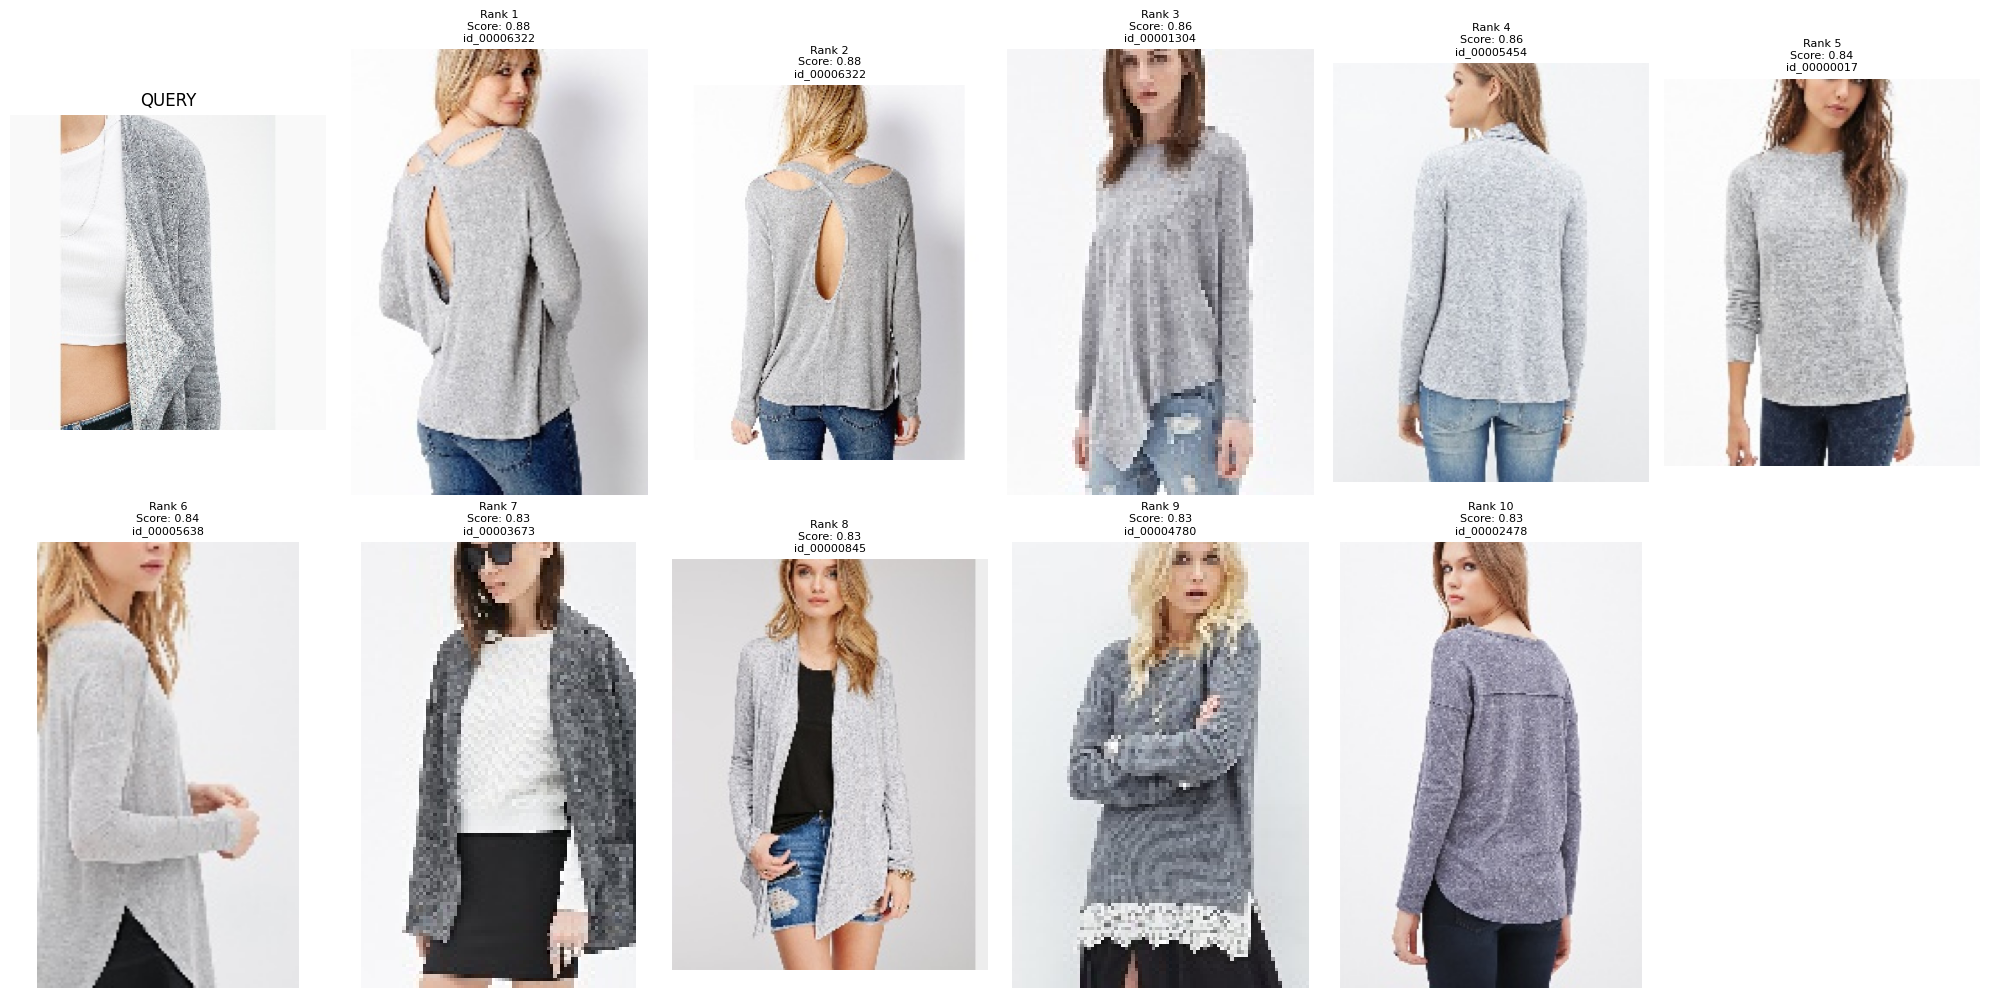


ONLINE MULTIMODAL RETRIEVAL COMPLETED!

QUERY ITEM ID:
id_00004804

TOP-K RETRIEVED ITEM IDs:

Rank 1: id_00006322
Rank 2: id_00006322
Rank 3: id_00001304
Rank 4: id_00005454
Rank 5: id_00000017
Rank 6: id_00005638
Rank 7: id_00003673
Rank 8: id_00000845
Rank 9: id_00004780
Rank 10: id_00002478

Retrieval Pipeline Working Successfully!


In [6]:
# ============================================================
# ONLINE MULTIMODAL RETRIEVAL PIPELINE
# ============================================================
#
# PIPELINE:
#
# Query Image
#  → YOLO-style crop (bbox annotations here)
#  → Fine-tuned CLIP image embedding
#  → BLIP caption generation
#  → CLIP text embedding
#  → Multimodal fusion
#  → FAISS retrieval
#  → Top-K visualization
#
# ============================================================

# ============================================================
# 1. INSTALL DEPENDENCIES
# ============================================================

print("\n[1/15] Installing Dependencies...\n")

!pip install -q transformers accelerate sentencepiece faiss-cpu matplotlib

print("\nDependencies Installed Successfully!")

# ============================================================
# 2. IMPORT LIBRARIES
# ============================================================

print("\n[2/15] Importing Libraries...\n")

import os
import cv2
import faiss
import torch
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm

from transformers import (
    CLIPProcessor,
    CLIPModel,
    BlipProcessor,
    BlipForConditionalGeneration
)

print("Libraries Imported Successfully!")

# ============================================================
# 3. DEVICE SETUP
# ============================================================

print("\n[3/15] Setting Up Device...\n")

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Using Device:", device)

# ============================================================
# 4. PATH CONFIGURATION
# ============================================================

print("\n[4/15] Configuring Paths...\n")

BASE_DATASET_PATH = "/kaggle/input/datasets/kunalnarang47/deepfashion-redwing2/DeepFashion"

MODEL_FILES_PATH = "/kaggle/input/datasets/kunalnarang47/model-files-vr"

IMG_BASE_PATH = os.path.join(
    BASE_DATASET_PATH,
    "Img"
)

BBOX_FILE = os.path.join(
    BASE_DATASET_PATH,
    "Anno",
    "list_bbox_inshop.txt"
)

BEST_MODEL_PATH = os.path.join(
    MODEL_FILES_PATH,
    "best_fashion_clip.pth"
)

print("Paths Configured Successfully!")

# ============================================================
# 5. LOAD FINAL RETRIEVAL DATABASE
# ============================================================

print("\n[5/15] Loading Optimized Retrieval Database...\n")

gallery_paths = np.load(
    os.path.join(
        MODEL_FILES_PATH,
        "gallery_paths.npy"
    ),
    allow_pickle=True
)

gallery_item_ids = np.load(
    os.path.join(
        MODEL_FILES_PATH,
        "gallery_item_ids.npy"
    ),
    allow_pickle=True
)

gallery_captions = np.load(
    os.path.join(
        MODEL_FILES_PATH,
        "optimized_gallery_captions.npy"
    ),
    allow_pickle=True
)

gallery_fusion_embeddings = np.load(
    os.path.join(
        MODEL_FILES_PATH,
        "optimized_gallery_fusion_embeddings.npy"
    )
)

print("Gallery Images:", len(gallery_paths))

# ============================================================
# 6. LOAD FAISS INDEX
# ============================================================

print("\n[6/15] Loading FAISS Index...\n")

fusion_index = faiss.read_index(
    os.path.join(
        MODEL_FILES_PATH,
        "optimized_fusion_faiss.index"
    )
)

print("FAISS Index Loaded Successfully!")

print("Indexed Embeddings:", fusion_index.ntotal)

# ============================================================
# 7. LOAD BOUNDING BOX FILE
# ============================================================

print("\n[7/15] Loading Bounding Boxes...\n")

bbox_df = pd.read_csv(
    BBOX_FILE,
    skiprows=2,
    sep=r"\s+",
    header=None
)

bbox_df.columns = [
    "image_path",
    "clothes_type",
    "pose_type",
    "x1",
    "y1",
    "x2",
    "y2"
]

bbox_lookup = {}

for _, row in tqdm(
    bbox_df.iterrows(),
    total=len(bbox_df),
    desc="Creating BBox Lookup"
):

    bbox_lookup[row["image_path"]] = (
        int(row["x1"]),
        int(row["y1"]),
        int(row["x2"]),
        int(row["y2"])
    )

print("\nBounding Box Lookup Ready!")

# ============================================================
# 8. LOAD MODELS
# ============================================================

print("\n[8/15] Loading Models...\n")

# ------------------------------------------------------------
# FINE-TUNED CLIP
# ------------------------------------------------------------

clip_model = CLIPModel.from_pretrained(
    "openai/clip-vit-base-patch32"
).to(device)

clip_model.load_state_dict(
    torch.load(
        BEST_MODEL_PATH,
        map_location=device
    )
)

clip_processor = CLIPProcessor.from_pretrained(
    "openai/clip-vit-base-patch32"
)

clip_model.eval()

# ------------------------------------------------------------
# BLIP
# ------------------------------------------------------------

blip_processor = BlipProcessor.from_pretrained(
    "Salesforce/blip-image-captioning-large"
)

blip_model = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-large",
    torch_dtype=torch.float16
).to(device)

blip_model.eval()

print("\nModels Loaded Successfully!")

# ============================================================
# 9. HELPER FUNCTIONS
# ============================================================

print("\n[9/15] Creating Helper Functions...\n")

# ------------------------------------------------------------
# CROP IMAGE
# ------------------------------------------------------------

def load_cropped_image(image_path):

    full_image_path = os.path.join(
        IMG_BASE_PATH,
        image_path
    )

    image = cv2.imread(full_image_path)

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    height, width, _ = image.shape

    x1, y1, x2, y2 = bbox_lookup[image_path]

    # ========================================================
    # ADD PADDING
    # ========================================================

    padding_x = int((x2 - x1) * 0.15)
    padding_y = int((y2 - y1) * 0.15)

    x1 = max(0, x1 - padding_x)
    y1 = max(0, y1 - padding_y)

    x2 = min(width, x2 + padding_x)
    y2 = min(height, y2 + padding_y)

    # ========================================================
    # CROP
    # ========================================================

    cropped_image = image[y1:y2, x1:x2]

    return Image.fromarray(cropped_image)

# ------------------------------------------------------------
# IMAGE EMBEDDING
# ------------------------------------------------------------

def get_image_embedding(pil_image):

    inputs = clip_processor(
        images=pil_image,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():

        vision_outputs = clip_model.vision_model(
            pixel_values=inputs["pixel_values"]
        )

        image_features = clip_model.visual_projection(
            vision_outputs.pooler_output
        )

    image_features = image_features / torch.norm(
        image_features,
        dim=-1,
        keepdim=True
    )

    return image_features.cpu().numpy()[0]

# ------------------------------------------------------------
# CAPTION GENERATION
# ------------------------------------------------------------

def generate_caption(pil_image):

    inputs = blip_processor(
        images=pil_image,
        return_tensors="pt"
    ).to(device, torch.float16)

    with torch.no_grad():

        generated_ids = blip_model.generate(
            **inputs,
            max_new_tokens=30
        )

    caption = blip_processor.batch_decode(
        generated_ids,
        skip_special_tokens=True
    )[0].strip()

    return caption

# ------------------------------------------------------------
# TEXT EMBEDDING
# ------------------------------------------------------------

def get_text_embedding(text):

    inputs = clip_processor.tokenizer(
        text,
        return_tensors="pt",
        padding=True,
        truncation=True
    ).to(device)

    with torch.no_grad():

        text_outputs = clip_model.text_model(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"]
        )

        text_features = clip_model.text_projection(
            text_outputs.pooler_output
        )

    text_features = text_features / torch.norm(
        text_features,
        dim=-1,
        keepdim=True
    )

    return text_features.cpu().numpy()[0]

print("Helper Functions Ready!")

# ============================================================
# 10. SELECT QUERY IMAGE
# ============================================================

print("\n[10/15] Selecting Query Image...\n")

query_df = pd.read_csv(
    os.path.join(
        MODEL_FILES_PATH,
        "query_df.csv"
    )
)

random_query = query_df.sample(1).iloc[0]

query_image_path = random_query["image_path"]

query_item_id = random_query["item_id"]

print("\nSelected Query Image:")
print(query_image_path)

print("\nGround Truth Item ID:")
print(query_item_id)

# ============================================================
# 11. PROCESS QUERY IMAGE
# ============================================================

print("\n[11/15] Processing Query Image...\n")

query_image = load_cropped_image(
    query_image_path
)

# ------------------------------------------------------------
# IMAGE EMBEDDING
# ------------------------------------------------------------

query_image_embedding = get_image_embedding(
    query_image
)

# ------------------------------------------------------------
# BLIP CAPTION
# ------------------------------------------------------------

query_caption = generate_caption(
    query_image
)

print("\nGenerated Caption:")
print(query_caption)

# ------------------------------------------------------------
# TEXT EMBEDDING
# ------------------------------------------------------------

query_text_embedding = get_text_embedding(
    query_caption
)

# ------------------------------------------------------------
# MULTIMODAL FUSION
# ------------------------------------------------------------

alpha = 0.7
beta = 0.3

query_fusion_embedding = (
    alpha * query_image_embedding
    +
    beta * query_text_embedding
)

query_fusion_embedding = (
    query_fusion_embedding
    /
    np.linalg.norm(query_fusion_embedding)
)

print("\nQuery Embedding Generated Successfully!")

# ============================================================
# 12. FAISS RETRIEVAL
# ============================================================

print("\n[12/15] Running FAISS Retrieval...\n")

TOP_K = 10

distances, indices = fusion_index.search(
    np.expand_dims(
        query_fusion_embedding.astype(np.float32),
        axis=0
    ),
    TOP_K
)

print("\nTop-K Retrieval Completed!")

# ============================================================
# 13. DISPLAY RETRIEVAL RESULTS
# ============================================================

print("\n[13/15] Preparing Retrieval Results...\n")

retrieved_paths = []
retrieved_scores = []
retrieved_item_ids = []
retrieved_captions = []

for rank, idx in enumerate(indices[0]):

    retrieved_paths.append(
        gallery_paths[idx]
    )

    retrieved_scores.append(
        distances[0][rank]
    )

    retrieved_item_ids.append(
        gallery_item_ids[idx]
    )

    retrieved_captions.append(
        gallery_captions[idx]
    )

print("\nRetrieved Results Prepared Successfully!")

# ============================================================
# 14. VISUALIZE RESULTS
# ============================================================

print("\n[14/15] Visualizing Results...\n")

plt.figure(figsize=(20, 10))

# ------------------------------------------------------------
# QUERY IMAGE
# ------------------------------------------------------------

plt.subplot(2, 6, 1)

plt.imshow(query_image)

plt.title("QUERY")

plt.axis("off")

# ------------------------------------------------------------
# RETRIEVED RESULTS
# ------------------------------------------------------------

for i in range(TOP_K):

    result_image = load_cropped_image(
        retrieved_paths[i]
    )

    plt.subplot(2, 6, i + 2)

    plt.imshow(result_image)

    title_text = (
        f"Rank {i+1}\n"
        f"Score: {retrieved_scores[i]:.2f}\n"
        f"{retrieved_item_ids[i]}"
    )

    # --------------------------------------------------------
    # HIGHLIGHT CORRECT MATCH
    # --------------------------------------------------------

    if retrieved_item_ids[i] == query_item_id:

        title_text += "\nMATCH"

    plt.title(
        title_text,
        fontsize=8
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

# ============================================================
# 15. FINAL SUMMARY
# ============================================================

print("\n================================================")
print("ONLINE MULTIMODAL RETRIEVAL COMPLETED!")
print("================================================")

print("\nQUERY ITEM ID:")
print(query_item_id)

print("\nTOP-K RETRIEVED ITEM IDs:\n")

for i in range(TOP_K):

    print(
        f"Rank {i+1}: "
        f"{retrieved_item_ids[i]}"
    )

print("\nRetrieval Pipeline Working Successfully!")

In [7]:
# ============================================================
# MULTIMODAL RETRIEVAL EVALUATION PIPELINE
# ============================================================
#
# EVALUATES:
# - Recall@K
# - NDCG@K
# - mAP@K
#
# ABLATION SETTINGS:
#
# A → Vision-only CLIP
# B → Frozen CLIP + BLIP
# C → Fine-tuned CLIP + BLIP
#
# ============================================================

# ============================================================
# 1. INSTALL DEPENDENCIES
# ============================================================

print("\n[1/16] Installing Dependencies...\n")

!pip install -q transformers accelerate sentencepiece faiss-cpu

print("\nDependencies Installed Successfully!")

# ============================================================
# 2. IMPORT LIBRARIES
# ============================================================

print("\n[2/16] Importing Libraries...\n")

import os
import cv2
import faiss
import torch
import random
import numpy as np
import pandas as pd

from PIL import Image
from tqdm import tqdm

from transformers import (
    CLIPProcessor,
    CLIPModel,
    BlipProcessor,
    BlipForConditionalGeneration
)

print("Libraries Imported Successfully!")

# ============================================================
# 3. DEVICE SETUP
# ============================================================

print("\n[3/16] Setting Up Device...\n")

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Using Device:", device)

# ============================================================
# 4. PATH CONFIGURATION
# ============================================================

print("\n[4/16] Configuring Paths...\n")

BASE_DATASET_PATH = "/kaggle/input/datasets/kunalnarang47/deepfashion-redwing2/DeepFashion"

MODEL_FILES_PATH = "/kaggle/input/datasets/kunalnarang47/model-files-vr"

IMG_BASE_PATH = os.path.join(
    BASE_DATASET_PATH,
    "Img"
)

BBOX_FILE = os.path.join(
    BASE_DATASET_PATH,
    "Anno",
    "list_bbox_inshop.txt"
)

BEST_MODEL_PATH = os.path.join(
    MODEL_FILES_PATH,
    "best_fashion_clip.pth"
)

print("Paths Configured Successfully!")

# ============================================================
# 5. LOAD DATA
# ============================================================

print("\n[5/16] Loading Retrieval Data...\n")

gallery_paths = np.load(
    os.path.join(
        MODEL_FILES_PATH,
        "gallery_paths.npy"
    ),
    allow_pickle=True
)

gallery_item_ids = np.load(
    os.path.join(
        MODEL_FILES_PATH,
        "gallery_item_ids.npy"
    ),
    allow_pickle=True
)

query_df = pd.read_csv(
    os.path.join(
        MODEL_FILES_PATH,
        "query_df.csv"
    )
)

print("Gallery Images:", len(gallery_paths))
print("Query Images:", len(query_df))

# ============================================================
# 6. LOAD FAISS INDICES
# ============================================================

print("\n[6/16] Loading FAISS Indices...\n")

# ------------------------------------------------------------
# BASELINE INDEX
# ------------------------------------------------------------

# ------------------------------------------------------------
# BASELINE INDEX
# ------------------------------------------------------------

baseline_image_embeddings = np.load(
    os.path.join(
        MODEL_FILES_PATH,
        "optimized_gallery_image_embeddings.npy"
    )
)

baseline_image_embeddings = baseline_image_embeddings.astype(
    np.float32
)

baseline_index = faiss.IndexFlatIP(
    baseline_image_embeddings.shape[1]
)

baseline_index.add(
    baseline_image_embeddings
)

print("\nBaseline Vision-Only Index Created!")
print(
    "Indexed Embeddings:",
    baseline_index.ntotal
)
# ------------------------------------------------------------
# MULTIMODAL FUSION INDEX
# ------------------------------------------------------------

fusion_index = faiss.read_index(
    os.path.join(
        MODEL_FILES_PATH,
        "fusion_faiss.index"
    )
)

# ------------------------------------------------------------
# OPTIMIZED FUSION INDEX
# ------------------------------------------------------------

optimized_index = faiss.read_index(
    os.path.join(
        MODEL_FILES_PATH,
        "optimized_fusion_faiss.index"
    )
)

print("All FAISS Indices Loaded Successfully!")

# ============================================================
# 7. LOAD BOUNDING BOX FILE
# ============================================================

print("\n[7/16] Loading Bounding Boxes...\n")

bbox_df = pd.read_csv(
    BBOX_FILE,
    skiprows=2,
    sep=r"\s+",
    header=None
)

bbox_df.columns = [
    "image_path",
    "clothes_type",
    "pose_type",
    "x1",
    "y1",
    "x2",
    "y2"
]

bbox_lookup = {}

for _, row in tqdm(
    bbox_df.iterrows(),
    total=len(bbox_df),
    desc="Creating BBox Lookup"
):

    bbox_lookup[row["image_path"]] = (
        int(row["x1"]),
        int(row["y1"]),
        int(row["x2"]),
        int(row["y2"])
    )

print("\nBounding Box Lookup Ready!")

# ============================================================
# 8. LOAD MODELS
# ============================================================

print("\n[8/16] Loading Models...\n")

# ------------------------------------------------------------
# BASELINE CLIP
# ------------------------------------------------------------

baseline_clip = CLIPModel.from_pretrained(
    "openai/clip-vit-base-patch32"
).to(device)

baseline_clip.eval()

# ------------------------------------------------------------
# FINE-TUNED CLIP
# ------------------------------------------------------------

optimized_clip = CLIPModel.from_pretrained(
    "openai/clip-vit-base-patch32"
).to(device)

optimized_clip.load_state_dict(
    torch.load(
        BEST_MODEL_PATH,
        map_location=device
    )
)

optimized_clip.eval()

# ------------------------------------------------------------
# PROCESSOR
# ------------------------------------------------------------

clip_processor = CLIPProcessor.from_pretrained(
    "openai/clip-vit-base-patch32"
)

# ------------------------------------------------------------
# BLIP
# ------------------------------------------------------------

blip_processor = BlipProcessor.from_pretrained(
    "Salesforce/blip-image-captioning-large"
)

blip_model = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-large",
    torch_dtype=torch.float16
).to(device)

blip_model.eval()

print("\nModels Loaded Successfully!")

# ============================================================
# 9. HELPER FUNCTIONS
# ============================================================

print("\n[9/16] Creating Helper Functions...\n")

# ------------------------------------------------------------
# PADDED CROP
# ------------------------------------------------------------

def load_cropped_image(image_path):

    full_image_path = os.path.join(
        IMG_BASE_PATH,
        image_path
    )

    image = cv2.imread(full_image_path)

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    height, width, _ = image.shape

    x1, y1, x2, y2 = bbox_lookup[image_path]

    padding_x = int((x2 - x1) * 0.15)
    padding_y = int((y2 - y1) * 0.15)

    x1 = max(0, x1 - padding_x)
    y1 = max(0, y1 - padding_y)

    x2 = min(width, x2 + padding_x)
    y2 = min(height, y2 + padding_y)

    cropped_image = image[y1:y2, x1:x2]

    return Image.fromarray(cropped_image)

# ------------------------------------------------------------
# IMAGE EMBEDDING
# ------------------------------------------------------------

def get_image_embedding(model, pil_image):

    inputs = clip_processor(
        images=pil_image,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():

        vision_outputs = model.vision_model(
            pixel_values=inputs["pixel_values"]
        )

        image_features = model.visual_projection(
            vision_outputs.pooler_output
        )

    image_features = image_features / torch.norm(
        image_features,
        dim=-1,
        keepdim=True
    )

    return image_features.cpu().numpy()[0]

# ------------------------------------------------------------
# CAPTION GENERATION
# ------------------------------------------------------------

def generate_caption(pil_image):

    inputs = blip_processor(
        images=pil_image,
        return_tensors="pt"
    ).to(device, torch.float16)

    with torch.no_grad():

        generated_ids = blip_model.generate(
            **inputs,
            max_new_tokens=30
        )

    caption = blip_processor.batch_decode(
        generated_ids,
        skip_special_tokens=True
    )[0].strip()

    return caption

# ------------------------------------------------------------
# TEXT EMBEDDING
# ------------------------------------------------------------

def get_text_embedding(model, text):

    inputs = clip_processor.tokenizer(
        text,
        return_tensors="pt",
        padding=True,
        truncation=True
    ).to(device)

    with torch.no_grad():

        text_outputs = model.text_model(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"]
        )

        text_features = model.text_projection(
            text_outputs.pooler_output
        )

    text_features = text_features / torch.norm(
        text_features,
        dim=-1,
        keepdim=True
    )

    return text_features.cpu().numpy()[0]

print("Helper Functions Ready!")

# ============================================================
# 10. RETRIEVAL SETTINGS
# ============================================================

print("\n[10/16] Configuring Evaluation...\n")

TOP_K_VALUES = [5, 10, 15]

NUM_QUERY_SAMPLES = 1000

alpha = 0.7
beta = 0.3

print("Evaluation Ready!")

# ============================================================
# 11. METRIC FUNCTIONS
# ============================================================

print("\n[11/16] Creating Metric Functions...\n")

# ------------------------------------------------------------
# RECALL@K
# ------------------------------------------------------------

def compute_recall_at_k(
    retrieved_ids,
    gt_id,
    k
):

    top_k = retrieved_ids[:k]

    return int(gt_id in top_k)

# ------------------------------------------------------------
# DCG
# ------------------------------------------------------------

def dcg(relevances):

    relevances = np.array(relevances)

    return np.sum(
        relevances
        /
        np.log2(
            np.arange(2, len(relevances) + 2)
        )
    )

# ------------------------------------------------------------
# NDCG@K
# ------------------------------------------------------------

def compute_ndcg_at_k(
    retrieved_ids,
    gt_id,
    k
):

    relevances = [
        1 if rid == gt_id else 0
        for rid in retrieved_ids[:k]
    ]

    ideal = sorted(
        relevances,
        reverse=True
    )

    actual_dcg = dcg(relevances)

    ideal_dcg = dcg(ideal)

    if ideal_dcg == 0:

        return 0

    return actual_dcg / ideal_dcg

# ------------------------------------------------------------
# AP@K
# ------------------------------------------------------------

def compute_ap_at_k(
    retrieved_ids,
    gt_id,
    k
):

    precisions = []

    hits = 0

    for i, rid in enumerate(retrieved_ids[:k]):

        if rid == gt_id:

            hits += 1

            precisions.append(
                hits / (i + 1)
            )

    if len(precisions) == 0:

        return 0

    return np.mean(precisions)

print("Metric Functions Ready!")

# ============================================================
# 12. ABLATION CONFIGS
# ============================================================

print("\n[12/16] Creating Ablation Settings...\n")

ABLATIONS = {

    "A_Vision_Only": {
        "model": baseline_clip,
        "index": baseline_index,
        "use_text": False
    },

    "B_Frozen_Multimodal": {
        "model": baseline_clip,
        "index": fusion_index,
        "use_text": True
    },

    "C_Finetuned_Multimodal": {
        "model": optimized_clip,
        "index": optimized_index,
        "use_text": True
    }
}

print("Ablation Configurations Ready!")

# ============================================================
# 13. RUN EVALUATION
# ============================================================

print("\n[13/16] Starting Evaluation...\n")

sampled_queries = query_df.sample(
    NUM_QUERY_SAMPLES,
    random_state=42
)

results = {}

for ablation_name, config in ABLATIONS.items():

    print(f"\n================================================")
    print(f"RUNNING: {ablation_name}")
    print("================================================\n")

    recall_scores = {
        5: [],
        10: [],
        15: []
    }

    ndcg_scores = {
        5: [],
        10: [],
        15: []
    }

    map_scores = {
        5: [],
        10: [],
        15: []
    }

    for idx, row in tqdm(
        sampled_queries.iterrows(),
        total=len(sampled_queries),
        desc=ablation_name
    ):

        query_path = row["image_path"]

        gt_id = row["item_id"]

        # ----------------------------------------------------
        # LOAD QUERY IMAGE
        # ----------------------------------------------------

        query_image = load_cropped_image(
            query_path
        )

        # ----------------------------------------------------
        # IMAGE EMBEDDING
        # ----------------------------------------------------

        image_embedding = get_image_embedding(
            config["model"],
            query_image
        )

        # ----------------------------------------------------
        # MULTIMODAL FUSION
        # ----------------------------------------------------

        if config["use_text"]:

            caption = generate_caption(
                query_image
            )

            text_embedding = get_text_embedding(
                config["model"],
                caption
            )

            query_embedding = (
                alpha * image_embedding
                +
                beta * text_embedding
            )

            query_embedding = (
                query_embedding
                /
                np.linalg.norm(query_embedding)
            )

        else:

            query_embedding = image_embedding

        # ----------------------------------------------------
        # SEARCH
        # ----------------------------------------------------

        distances, indices = config["index"].search(
            np.expand_dims(
                query_embedding.astype(np.float32),
                axis=0
            ),
            15
        )

        retrieved_ids = [
            gallery_item_ids[i]
            for i in indices[0]
        ]

        # ----------------------------------------------------
        # METRICS
        # ----------------------------------------------------

        for k in TOP_K_VALUES:

            recall_scores[k].append(
                compute_recall_at_k(
                    retrieved_ids,
                    gt_id,
                    k
                )
            )

            ndcg_scores[k].append(
                compute_ndcg_at_k(
                    retrieved_ids,
                    gt_id,
                    k
                )
            )

            map_scores[k].append(
                compute_ap_at_k(
                    retrieved_ids,
                    gt_id,
                    k
                )
            )

    # --------------------------------------------------------
    # STORE FINAL RESULTS
    # --------------------------------------------------------

    results[ablation_name] = {

        "Recall@5":
            np.mean(recall_scores[5]),

        "Recall@10":
            np.mean(recall_scores[10]),

        "Recall@15":
            np.mean(recall_scores[15]),

        "NDCG@5":
            np.mean(ndcg_scores[5]),

        "NDCG@10":
            np.mean(ndcg_scores[10]),

        "NDCG@15":
            np.mean(ndcg_scores[15]),

        "mAP@5":
            np.mean(map_scores[5]),

        "mAP@10":
            np.mean(map_scores[10]),

        "mAP@15":
            np.mean(map_scores[15])
    }

# ============================================================
# 14. CREATE RESULTS TABLE
# ============================================================

print("\n[14/16] Creating Results Table...\n")

results_df = pd.DataFrame(results).T

print("\n================================================")
print("FINAL EVALUATION RESULTS")
print("================================================\n")

print(results_df)

# ============================================================
# 15. SAVE RESULTS
# ============================================================

print("\n[15/16] Saving Results...\n")

results_df.to_csv(
    "retrieval_evaluation_results.csv"
)

print("\nResults Saved Successfully!")

# ============================================================
# 16. FINAL SUMMARY
# ============================================================

print("\n================================================")
print("MULTIMODAL RETRIEVAL EVALUATION COMPLETED!")
print("================================================")

print("\nFILE GENERATED:")
print("\n1. retrieval_evaluation_results.csv")

print("\nEvaluation Pipeline Working Successfully!")


[1/16] Installing Dependencies...


Dependencies Installed Successfully!

[2/16] Importing Libraries...

Libraries Imported Successfully!

[3/16] Setting Up Device...

Using Device: cuda

[4/16] Configuring Paths...

Paths Configured Successfully!

[5/16] Loading Retrieval Data...

Gallery Images: 12612
Query Images: 14218

[6/16] Loading FAISS Indices...


Baseline Vision-Only Index Created!
Indexed Embeddings: 12612
All FAISS Indices Loaded Successfully!

[7/16] Loading Bounding Boxes...



Creating BBox Lookup: 100%|██████████| 52712/52712 [00:02<00:00, 24029.10it/s]



Bounding Box Lookup Ready!

[8/16] Loading Models...



Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...


RUNNING: B_Frozen_Multimodal



B_Frozen_Multimodal: 100%|██████████| 1000/1000 [04:56<00:00,  3.37it/s]



RUNNING: C_Finetuned_Multimodal



C_Finetuned_Multimodal: 100%|██████████| 1000/1000 [04:55<00:00,  3.38it/s]


[14/16] Creating Results Table...


FINAL EVALUATION RESULTS

                        Recall@5  Recall@10  Recall@15    NDCG@5   NDCG@10  \
A_Vision_Only              0.087      0.122      0.148  0.061402  0.071535   
B_Frozen_Multimodal        0.459      0.534      0.578  0.361239  0.378288   
C_Finetuned_Multimodal     0.702      0.775      0.820  0.611724  0.626912   

                         NDCG@15     mAP@5    mAP@10    mAP@15  
A_Vision_Only           0.077744  0.052239  0.054065  0.054164  
B_Frozen_Multimodal     0.386084  0.324511  0.316907  0.310692  
C_Finetuned_Multimodal  0.629417  0.573136  0.562287  0.544435  

[15/16] Saving Results...


Results Saved Successfully!

MULTIMODAL RETRIEVAL EVALUATION COMPLETED!

FILE GENERATED:

1. retrieval_evaluation_results.csv

Evaluation Pipeline Working Successfully!
